In [3]:
# 安装需要的库（第一次运行执行，后续可以注释掉）
!pip install pandas plotly shap scikit-learn matplotlib numpy

# 导包
import pandas as pd
import plotly.express as px
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv(r'C:\Users\xys\Downloads\emerald_data.csv')
# ==============================================================



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,unique_id,claim,gold_label,company,justification
0,0,EVgo and Amazon partner to enable voice-initia...,not_greenwashing,EVgo / Amazon,This is a factual statement describing the new...
1,1,"Amazon's Alexa now helps EV drivers find, navi...",not_greenwashing,Amazon,This is a factual description of the new featu...
2,2,Delta reduced its onboard single-use plastic c...,not_greenwashing,Delta,"This is a specific, quantifiable achievement d..."
3,3,"Delta announces a ""zero-waste flight"" as part ...",not_greenwashing,Delta,"The ""zero-waste flight"" was a specific, one-of..."
4,4,Delta is using more fuel-efficient A321neo air...,not_greenwashing,Delta,"This is a specific, verifiable improvement in ..."


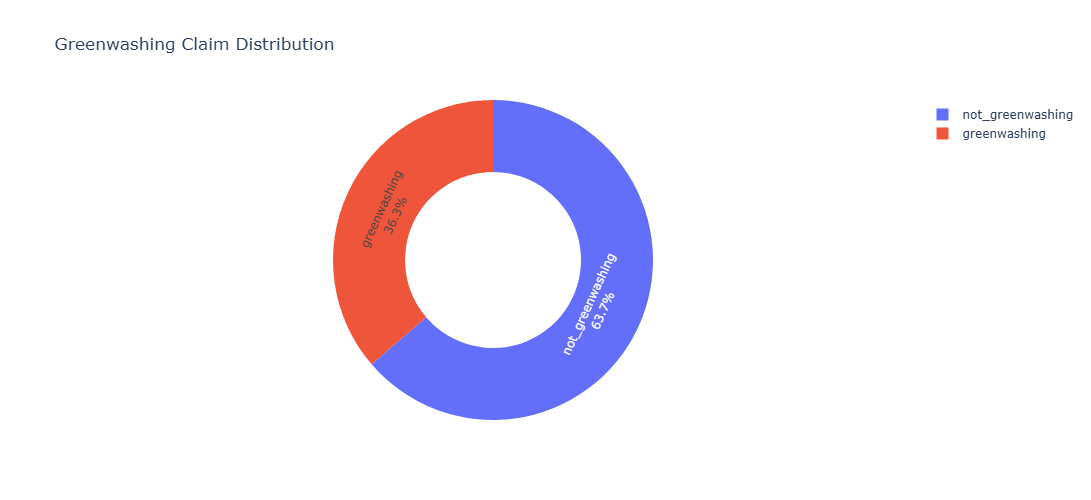

In [4]:
# Figure1 甜甜圈圆环图 标签类别分布
counts = df['gold_label'].value_counts()

fig1 = px.pie(
    values=counts.values,
    names=counts.index,
    hole=0.55,  # 圆环粗细
    title='Greenwashing Claim Distribution'
)

# 文字放在环内、显示百分比+类别名
fig1.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

# IEEE海报优化：纯白背景+固定尺寸
fig1.update_layout(
    width=700,
    height=500,
    template='plotly_white'
)

fig1.show()

# 【导出高清海报图】 scale=3=3倍分辨率，存到本地
# fig1.write_image("Fig1_Donut.png", scale=3)

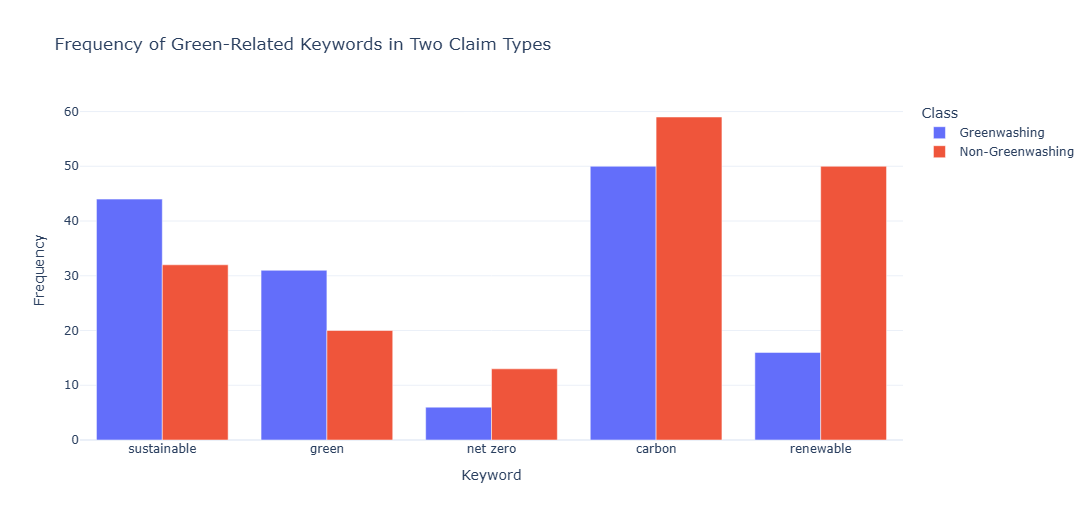

In [12]:
# Figure4 分组柱状：5个关键词在两类样本出现频次
keywords = ['sustainable', 'green', 'net zero', 'carbon', 'renewable']
save_data = []

# 循环统计每个关键词在GW/非GW里出现数量（不区分大小写匹配文本）
for kw in keywords:
    # greenwashing类包含关键词数量
    gw_num = df[(df["gold_label"]=="greenwashing") & (df["claim"].str.contains(kw, case=False, na=False))].shape[0]
    # non-greenwashing类包含关键词数量
    non_gw_num = df[(df["gold_label"]!="greenwashing") & (df["claim"].str.contains(kw, case=False, na=False))].shape[0]
    
    save_data.append({"Keyword":kw, "Frequency":gw_num, "Class":"Greenwashing"})
    save_data.append({"Keyword":kw, "Frequency":non_gw_num, "Class":"Non-Greenwashing"})

keyword_df = pd.DataFrame(save_data)

fig4 = px.bar(
    keyword_df,
    x="Keyword",
    y="Frequency",
    color="Class",
    barmode="group",  # 并列分组
    title='Frequency of Green-Related Keywords in Two Claim Types'
)

fig4.update_layout(
    width=850,
    height=520,
    template='plotly_white'
)

fig4.show()
# fig4.write_image("Fig4_GroupBar.png", scale=3)

<Figure size 800x500 with 0 Axes>

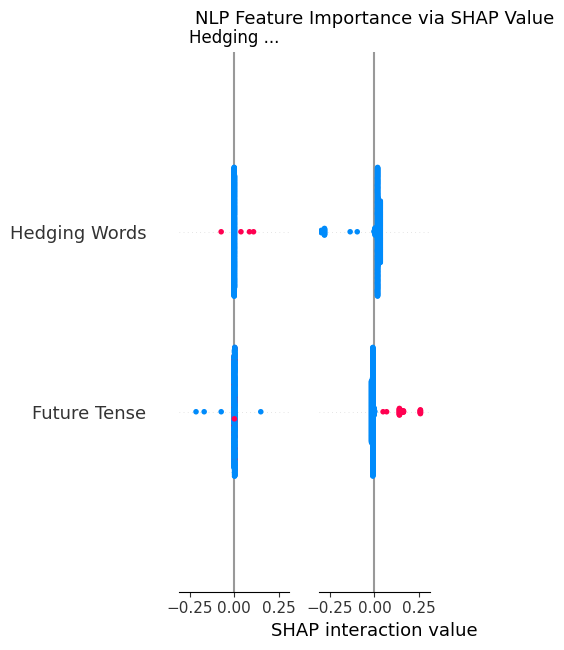

In [16]:
import re
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

# =========1. 关键：删除gold_label为空的样本，消除y里的NaN=========
df = df.dropna(subset=["gold_label"]).copy()

# 特征函数
def get_hedging(text):
    hedges = ['may','might','could','possibly','likely','perhaps']
    return sum(1 for w in hedges if w in str(text).lower().split())
def get_future_tense(text):
    future = ['will','shall','would','going to']
    return sum(1 for w in future if w in str(text).lower())
def get_vague_term(text):
    vague = ['some','several','many','soon','roughly','around']
    return sum(1 for w in vague if w in str(text).lower())
def get_passive(text):
    return len(re.findall(r'(was|is|are|been)\s+\w+ed',str(text).lower()))
def get_quant_data(text):
    return len(re.findall(r'\d+',str(text)))

# 生成5个特征列
df['Hedging Words'] = df['claim'].apply(get_hedging)
df['Future Tense'] = df['claim'].apply(get_future_tense)
df['Vague Terms'] = df['claim'].apply(get_vague_term)
df['Passive Voice'] = df['claim'].apply(get_passive)
df['Quantitative Data'] = df['claim'].apply(get_quant_data)

# 数据集
feat_cols = ['Hedging Words','Future Tense','Vague Terms','Passive Voice','Quantitative Data']
X = df[feat_cols].copy()
y = df['gold_label'].map({"greenwashing":1, "not_greenwashing":0})

# 再次剔除y残留空值（兜底）
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]

# 训练模型
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X)

# =========2. 修复标题和图表重叠代码=========
plt.figure(figsize=(8,5))
shap.summary_plot(shap_vals, X, plot_type="bar", show=False)
plt.subplots_adjust(top=0.77)  # 顶部留白变大，数值越小留白越多
plt.title("NLP Feature Importance via SHAP Value", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

# plt.savefig("Fig5_SHAP.png", dpi=300, bbox_inches="tight")